In [2]:
%config InlineBackend.figure_format = 'svg'
import pandas as pd
import pickle
def load_pickle(fp):
    with open(fp,'rb') as stream:
        out = pickle.load(stream)
    return out
ground_truth = pd.read_csv('./R_results/ground_truth.csv')
ground_truth['ground_truth'] = ground_truth['n_SI'].values
ground_truth = ground_truth[['T','ground_truth']]
customGP_results = load_pickle('./py_results/results_CustomGP_budget_700_rep1.pkl')


import numpy as np

def parse_results(results):
    df = pd.DataFrame(np.concatenate(results['X_list'],axis=0),columns=['beta','gamma','seed'])
    df['Y'] = np.concat(results['y_list'])
    df['sim_id'] = range(len(df))
    # calculate best observed value (bov)
    df['bov'] = np.minimum.accumulate(df['Y'])
    return df

df_customGP = parse_results(customGP_results)
df_customGP['seed'] = df_customGP['seed'].astype(int)
df_customGP


,beta,gamma,seed,Y,sim_id,bov
0,0.984053,0.629322,1,0.125579,0,0.125579
1,0.984053,0.629322,2,1.018717,1,0.125579
2,0.984053,0.629322,3,0.727971,2,0.125579
3,0.984053,0.629322,4,1.109894,3,0.125579
4,0.984053,0.629322,5,0.699863,4,0.125579
...,...,...,...,...,...,...
698,0.340937,0.228817,10,-2.980878,698,-3.098296
699,0.622601,0.548418,3,-2.453391,699,-3.098296
700,0.446342,0.323837,3,-2.044255,700,-3.098296
701,0.961696,0.911234,3,-0.906411,701,-3.098296


In [3]:
import torch
from adaptive_TS import CustomGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
X = df_customGP[['beta','gamma','seed']].values
Y = df_customGP['Y'].values

X, Y = torch.from_numpy(X), torch.from_numpy(Y)
def fitGP(rank):

    model = CustomGP(train_inputs=X, train_targets=Y,likelihood=GaussianLikelihood(),num_tasks=10,rank = rank)
    mll = ExactMarginalLogLikelihood(likelihood=model.likelihood,model=model)
    fit_gpytorch_mll(mll)

    return model
model_rank1 = fitGP(rank = 1)
model_rank5 = fitGP(rank = 5)
model_rank10 = fitGP(rank = 10)


/Users/dogara/code/AdaptiveTS/adaptiveTS/adaptiveTS-odin-python/venv/lib/python3.10/site-packages/linear_operator/utils/interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:656.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)


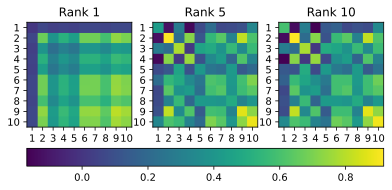

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors
def B_gram(model):
    B = model.task_covariance_module.covar_factor
    return (B @ B.T).detach().numpy()

gram_rank1 = B_gram(model_rank1)
gram_rank5 = B_gram(model_rank5 )
gram_rank10 = B_gram(model_rank10)



fig, ax = plt.subplots(ncols=3)
gram_data = [gram_rank1,gram_rank5,gram_rank10]
norm = colors.Normalize(vmin = np.min(gram_data), vmax = np.max(gram_data))
images = []
titles = ['Rank 1', 'Rank 5', 'Rank 10']
for i, gram in enumerate(gram_data):
    im = ax[i].imshow(gram,norm=norm); 
    ax[i].set_title(titles[i])
    ax[i].set_xticks(ticks = np.arange(10), labels = np.arange(10) + 1)
    ax[i].set_yticks(ticks = np.arange(10), labels = np.arange(10) + 1)
    images.append(im)
fig.colorbar(images[0], ax=ax, orientation='horizontal', fraction=.1, pad=0.08)
fig.suptitle("Random Seed Relationships")
